<a href="https://colab.research.google.com/github/JordanTerwilliger/Intro-to-Deep-Learning/blob/main/HW2/HW2_LanguageProcessing_RNN_Q2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Jordan Terwilliger, 801343938, HW2

In [10]:
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np
import requests

from torch import nn
from torch import functional as F
from torch import optim

!pip install torchinfo

import matplotlib.pyplot as plt

from torchinfo import summary

In [11]:
torch.manual_seed(1)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
#hyperparameters
lr = 1e-4
epochs = 30
hidden_size = 512

device

device(type='cuda', index=0)

In [12]:

#Imported directly from Dr. Tabkhi's Github
# Step 1: Download the dataset
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
response = requests.get(url)
text = response.text  # This is the entire text data
chars = sorted(list(set(text)))
char_to_int = {ch: i for i, ch in enumerate(chars)}
int_to_char = {i: ch for i, ch in enumerate(chars)}
def createTrainAndTestLoaders(sequence_length):



  # Encode the text into integers
  encoded_text = [char_to_int[ch] for ch in text]

  # Create sequences and targets
  sequences = []
  targets = []
  for i in range(0, len(encoded_text) - sequence_length):
      seq = encoded_text[i:i+sequence_length]
      target = encoded_text[i+sequence_length]
      sequences.append(seq)
      targets.append(target)

  # Convert lists to PyTorch tensors
  sequences = torch.tensor(sequences, dtype=torch.long)
  targets = torch.tensor(targets, dtype=torch.long)

  # Step 3: Create a dataset class
  class CharDataset(Dataset):
      def __init__(self, sequences, targets):
          self.sequences = sequences
          self.targets = targets

      def __len__(self):
          return len(self.sequences)

      def __getitem__(self, index):
          return self.sequences[index], self.targets[index]

  # Instantiate the dataset
  dataset = CharDataset(sequences, targets)

  # Step 4: Create data loaders
  batch_size = 1024
  train_size = int(len(dataset) * 0.8)
  test_size = len(dataset) - train_size
  train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])

  train_loader = DataLoader(train_dataset, shuffle=True, batch_size=batch_size, pin_memory=True)
  test_loader = DataLoader(test_dataset, shuffle=False, batch_size=batch_size, pin_memory=True)

  if(train_loader and test_loader):
    print(f"Train and Test Loader Created - Sequence Length: {sequence_length}")
    return train_loader, test_loader
  else:
    print("Not created")

  # Now `train_loader` and `test_loader` are ready to be used in a training loop

In [13]:
# We need to convert this text into a list of sorted indices for
print(f"Total Input Characters: {len(text)}")
sorted_text = list(sorted(set(text)))
print(f"Total Unique Characters: {len(sorted_text)}")
print(sorted_text)

ix_to_char = {i: ch for i,ch in enumerate(sorted_text)}
print(ix_to_char)

char_to_ix = {ch: i for i, ch in enumerate(sorted_text)}

Total Input Characters: 1115394
Total Unique Characters: 65
['\n', ' ', '!', '$', '&', "'", ',', '-', '.', '3', ':', ';', '?', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
{0: '\n', 1: ' ', 2: '!', 3: '$', 4: '&', 5: "'", 6: ',', 7: '-', 8: '.', 9: '3', 10: ':', 11: ';', 12: '?', 13: 'A', 14: 'B', 15: 'C', 16: 'D', 17: 'E', 18: 'F', 19: 'G', 20: 'H', 21: 'I', 22: 'J', 23: 'K', 24: 'L', 25: 'M', 26: 'N', 27: 'O', 28: 'P', 29: 'Q', 30: 'R', 31: 'S', 32: 'T', 33: 'U', 34: 'V', 35: 'W', 36: 'X', 37: 'Y', 38: 'Z', 39: 'a', 40: 'b', 41: 'c', 42: 'd', 43: 'e', 44: 'f', 45: 'g', 46: 'h', 47: 'i', 48: 'j', 49: 'k', 50: 'l', 51: 'm', 52: 'n', 53: 'o', 54: 'p', 55: 'q', 56: 'r', 57: 's', 58: 't', 59: 'u', 60: 'v', 61: 'w', 62: 'x', 63: 'y', 64: 'z'}


In [14]:
class BasicLSTM(nn.Module):
  def __init__(self, input_size, output_size, hidden_size = 100, dropout_rate = 0.0):
    super(BasicLSTM,self).__init__()
    self.embedding = nn.Embedding(input_size, hidden_size)
    self.lstm = nn.LSTM(input_size = hidden_size, hidden_size=hidden_size, batch_first = True, num_layers=1, dropout=dropout_rate)
    self.fc1 = nn.Linear(in_features = hidden_size, out_features = output_size)
    self.dropout = nn.Dropout(p = dropout_rate)

  def forward(self, x):
    embedded = self.embedding(x)
    output,_ = self.lstm(embedded)
    output = self.dropout(output[:, -1, :])
    output = self.fc1(output)
    return output

class BasicGRU(nn.Module):
  def __init__(self, input_size,  output_size, hidden_size = 100, dropout_rate = 0.0):
    super(BasicGRU,self).__init__()
    self.embedding = nn.Embedding(input_size, hidden_size)
    self.gru = nn.GRU(input_size = hidden_size, hidden_size=hidden_size, batch_first = True, num_layers=1, dropout = dropout_rate)
    self.dropout = nn.Dropout(p = dropout_rate)
    self.fc1 = nn.Linear(in_features = hidden_size, out_features = output_size)

  def forward(self, x):
    embedded = self.embedding(x)
    output,_ = self.gru(embedded)
    output = self.dropout(output[:, -1, :])
    output = self.fc1(output)
    return output


#Modified networks contain an additional FC layer, more hidden layers, and a greater hidden size

class ModifiedLSTM(nn.Module):
  def __init__(self, input_size, output_size, fc_connections, hidden_size = 512, dropout_rate = 0.0):
    super(ModifiedLSTM,self).__init__()
    self.embedding = nn.Embedding(input_size, hidden_size)
    self.lstm = nn.LSTM(input_size = hidden_size, hidden_size=hidden_size, batch_first = True, num_layers=3, dropout=dropout_rate)
    self.dropout = nn.Dropout(p = dropout_rate)
    self.fc1 = nn.Linear(hidden_size, fc_connections)
    self.fc2 = nn.Linear(fc_connections, output_size)

  def forward(self, x):
    embedded = self.embedding(x)
    output,_ = self.lstm(embedded)
    output = self.dropout(output[:, -1, :])
    output = self.fc1(output)
    output = self.fc2(output)
    return output


class ModifiedGRU(nn.Module):
  def __init__(self, input_size, output_size, fc_connections, hidden_size = 512, dropout_rate = 0.0):
    super(ModifiedGRU,self).__init__()
    self.embedding = nn.Embedding(input_size, hidden_size)
    self.gru = nn.GRU(input_size = hidden_size, hidden_size=hidden_size, batch_first = True, num_layers=3, dropout = dropout_rate)
    self.dropout = nn.Dropout(p = dropout_rate)
    self.fc1 = nn.Linear(hidden_size, fc_connections)
    self.fc2 = nn.Linear(fc_connections, output_size)

  def forward(self, x):
    embedded = self.embedding(x)
    output,_ = self.gru(embedded)
    output = self.dropout(output[:, -1, :])
    output = self.fc1(output)
    output = self.fc2(output)
    return output



In [15]:
def createPlot(sequence_length, train_loss_list, val_loss_list, val_accuracy_list):
  plt.figure(figsize=(12, 5))

  # Plot Loss
  plt.subplot(1, 2, 1)
  plt.plot(train_loss_list, label='Train Loss')
  plt.plot(val_loss_list, label='Val Loss')
  plt.title(f'Loss Curves Sequence Length:{sequence_length}')
  plt.xlabel("Epoch")
  plt.ylabel("Loss")
  plt.legend()

  # Plot Accuracy
  plt.subplot(1, 2, 2)
  plt.plot(val_accuracy_list, label='Val Accuracy')
  plt.title(f'Validation Accuracy Sequence Length:{sequence_length}')
  plt.xlabel('Epoch')
  plt.ylabel('Accuracy (%)')
  plt.legend()

  plt.show()

In [20]:
def run(model, input_length = 20):
##Data Preprocessing and converting to tensor
  train_loader, test_loader = createTrainAndTestLoaders(input_length)
  criterion = nn.CrossEntropyLoss()
  optimizer = optim.Adam(model.parameters(), lr = lr)

  ###This is where training begins
  #Lists for storing loss and validation values
  train_loss_list = []
  val_loss_list = []
  val_accuracy_list = []
  time_list = []

  start_event = torch.cuda.Event(enable_timing=True)
  end_event = torch.cuda.Event(enable_timing=True)
  #Create a new training loop for each input_length
  for epoch in range(epochs):
    start_event.record()
    model.train()

    for data in train_loader:
      X_train, y_train = data
      X_train = X_train.to(device)
      y_train = y_train.to(device)
      optimizer.zero_grad()
      y_pred = model(X_train)  # Forward pass
      loss = criterion(y_pred, y_train)  # Compute loss
      loss.backward()  # Backward pass
      optimizer.step()  # Update model parameters

    end_event.record()
    torch.cuda.synchronize()
    time_list.append(start_event.elapsed_time(end_event))
    train_loss_list.append(loss.item()) #Take this epoch's training loss and add it
                                        #to the training loss list (of all epochs)


    #Here is where we evaluate the model on the current epoch
    model.eval()
    with torch.no_grad():
      for data in test_loader:
        X_val, y_val = data
        X_val = X_val.to(device)
        y_val = y_val.to(device)
        val_output = model(X_val) # Take test dataset and run it through this epoch's model

        val_loss = criterion(val_output, y_val) #Find the loss

        _, predicted = torch.max(val_output, 1) #Here we find what the output was (what letter)

        val_accuracy = (predicted == y_val).float().mean() #Here we take each answer from out model,
                                                          #compare it to the ground truth, and find how accurate we are

      val_loss_list.append(val_loss.item())
      val_accuracy_list.append(val_accuracy.item())


      print(f'Epoch {epoch}, Loss: {loss.item():.4f}, Val Accuracy: {val_accuracy.item():.4f}, Val Loss: {val_loss.item():.4f}, Training Time: {time_list[-1]}ms')
  return train_loss_list, val_loss_list, val_accuracy_list, time_list



#1. Basic Models - Input Length 20

##LSTM

Train and Test Loader Created - Sequence Length: 20
Epoch 0, Loss: 2.5036, Val Accuracy: 0.3080, Val Loss: 2.5665, Training Time: 8663.51953125ms
Epoch 1, Loss: 2.2636, Val Accuracy: 0.3322, Val Loss: 2.3195, Training Time: 8640.6748046875ms
Epoch 2, Loss: 2.1053, Val Accuracy: 0.3737, Val Loss: 2.1879, Training Time: 8866.6669921875ms
Epoch 3, Loss: 2.0662, Val Accuracy: 0.4014, Val Loss: 2.0969, Training Time: 8675.20703125ms
Epoch 4, Loss: 2.0652, Val Accuracy: 0.4302, Val Loss: 2.0281, Training Time: 8951.484375ms
Epoch 5, Loss: 1.9385, Val Accuracy: 0.4383, Val Loss: 1.9751, Training Time: 8786.2919921875ms
Epoch 6, Loss: 1.9151, Val Accuracy: 0.4521, Val Loss: 1.9310, Training Time: 8799.7626953125ms
Epoch 7, Loss: 1.9300, Val Accuracy: 0.4660, Val Loss: 1.8969, Training Time: 8963.3271484375ms
Epoch 8, Loss: 2.0317, Val Accuracy: 0.4729, Val Loss: 1.8712, Training Time: 8839.423828125ms
Epoch 9, Loss: 1.8417, Val Accuracy: 0.4798, Val Loss: 1.8461, Training Time: 8785.9013671875

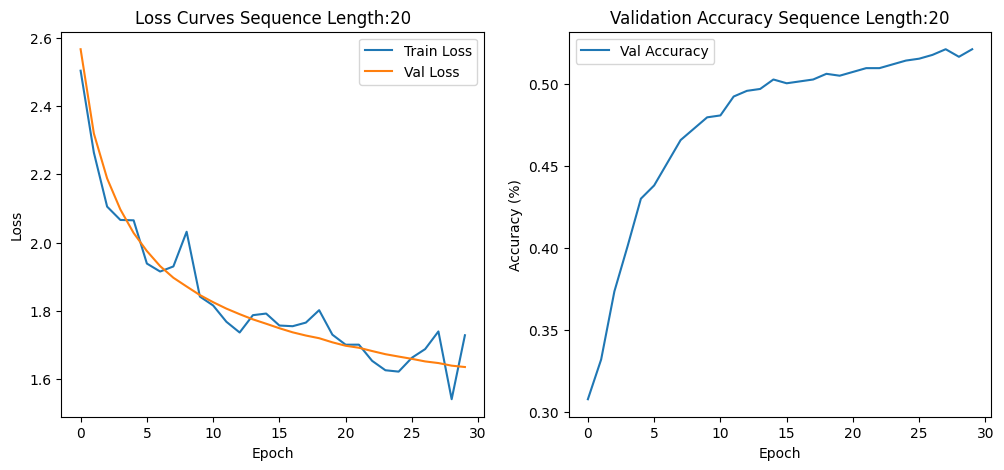

Layer (type:depth-idx)                   Output Shape              Param #
BasicLSTM                                [1, 65]                   --
├─Embedding: 1-1                         [1, 20, 100]              6,500
├─LSTM: 1-2                              [1, 20, 100]              80,800
├─Dropout: 1-3                           [1, 100]                  --
├─Linear: 1-4                            [1, 65]                   6,565
Total params: 93,865
Trainable params: 93,865
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 1.63
Input size (MB): 0.00
Forward/backward pass size (MB): 0.03
Params size (MB): 0.38
Estimated Total Size (MB): 0.41


In [21]:
input_length = 20
model = BasicLSTM(len(sorted_text), len(sorted_text)).to(device)
train_loss_list, val_loss_list, val_accuracy_list, time_list = run(model, input_length)
print(f"avg_time = {sum(time_list) / len(time_list)}")
createPlot(input_length, train_loss_list, val_loss_list, val_accuracy_list)
print(summary(model, input_size = (1,input_length), dtypes=[torch.long]))

##GRU

Train and Test Loader Created - Sequence Length: 20
Epoch 0, Loss: 2.4966, Val Accuracy: 0.2907, Val Loss: 2.5789, Training Time: 8523.0625ms
Epoch 1, Loss: 2.3582, Val Accuracy: 0.3172, Val Loss: 2.3474, Training Time: 8701.3193359375ms
Epoch 2, Loss: 2.1490, Val Accuracy: 0.3345, Val Loss: 2.2289, Training Time: 8524.3935546875ms
Epoch 3, Loss: 2.0030, Val Accuracy: 0.3495, Val Loss: 2.1479, Training Time: 8537.6923828125ms
Epoch 4, Loss: 2.0155, Val Accuracy: 0.3622, Val Loss: 2.0894, Training Time: 8481.8154296875ms
Epoch 5, Loss: 1.8692, Val Accuracy: 0.3806, Val Loss: 2.0443, Training Time: 8544.0947265625ms
Epoch 6, Loss: 1.9976, Val Accuracy: 0.3899, Val Loss: 2.0085, Training Time: 8502.791015625ms
Epoch 7, Loss: 1.7984, Val Accuracy: 0.4002, Val Loss: 1.9814, Training Time: 8557.5869140625ms
Epoch 8, Loss: 1.8695, Val Accuracy: 0.4164, Val Loss: 1.9565, Training Time: 8436.1962890625ms
Epoch 9, Loss: 1.8951, Val Accuracy: 0.4210, Val Loss: 1.9336, Training Time: 8554.27148437

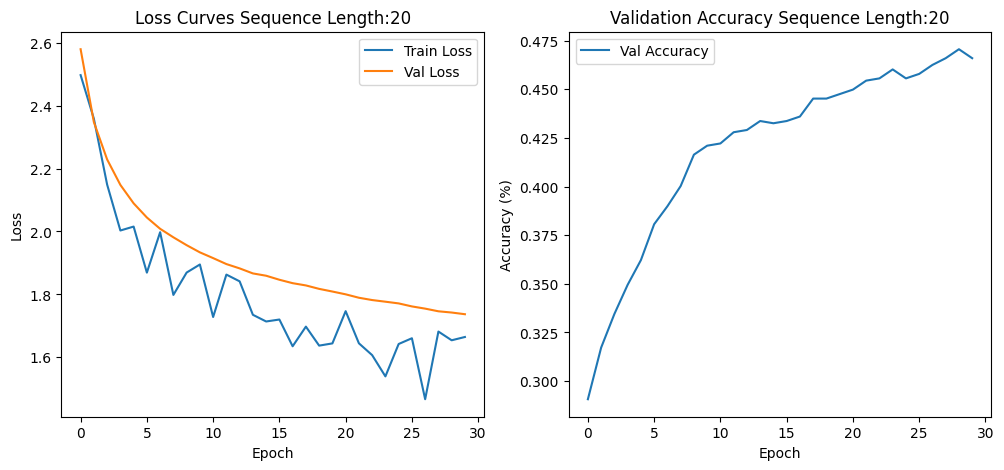

Layer (type:depth-idx)                   Output Shape              Param #
BasicGRU                                 [1, 65]                   --
├─Embedding: 1-1                         [1, 20, 100]              6,500
├─GRU: 1-2                               [1, 20, 100]              60,600
├─Dropout: 1-3                           [1, 100]                  --
├─Linear: 1-4                            [1, 65]                   6,565
Total params: 73,665
Trainable params: 73,665
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 1.23
Input size (MB): 0.00
Forward/backward pass size (MB): 0.03
Params size (MB): 0.29
Estimated Total Size (MB): 0.33


In [22]:
input_length = 20
model = BasicGRU(len(sorted_text), len(sorted_text)).to(device)
train_loss_list, val_loss_list, val_accuracy_list, time_list = run(model, input_length)
print(f"avg_time = {sum(time_list) / len(time_list)}")
createPlot(input_length, train_loss_list, val_loss_list, val_accuracy_list)
print(summary(model, input_size = (1,input_length), dtypes=[torch.long]))

#Basic Models - Input Length 30

##LSTM

Train and Test Loader Created - Sequence Length: 30
Epoch 0, Loss: 2.5803, Val Accuracy: 0.3064, Val Loss: 2.5824, Training Time: 7381.51953125ms
Epoch 1, Loss: 2.2622, Val Accuracy: 0.3468, Val Loss: 2.3353, Training Time: 8661.853515625ms
Epoch 2, Loss: 2.2172, Val Accuracy: 0.3873, Val Loss: 2.2116, Training Time: 8592.0458984375ms
Epoch 3, Loss: 2.1504, Val Accuracy: 0.4023, Val Loss: 2.1207, Training Time: 8626.4384765625ms
Epoch 4, Loss: 2.0001, Val Accuracy: 0.4208, Val Loss: 2.0515, Training Time: 8533.4765625ms
Epoch 5, Loss: 1.9353, Val Accuracy: 0.4324, Val Loss: 2.0005, Training Time: 8546.6025390625ms
Epoch 6, Loss: 2.0472, Val Accuracy: 0.4416, Val Loss: 1.9594, Training Time: 8610.5478515625ms
Epoch 7, Loss: 1.8617, Val Accuracy: 0.4451, Val Loss: 1.9310, Training Time: 8604.1572265625ms
Epoch 8, Loss: 1.8802, Val Accuracy: 0.4590, Val Loss: 1.9070, Training Time: 8636.0341796875ms
Epoch 9, Loss: 1.8335, Val Accuracy: 0.4566, Val Loss: 1.8836, Training Time: 8583.7314453

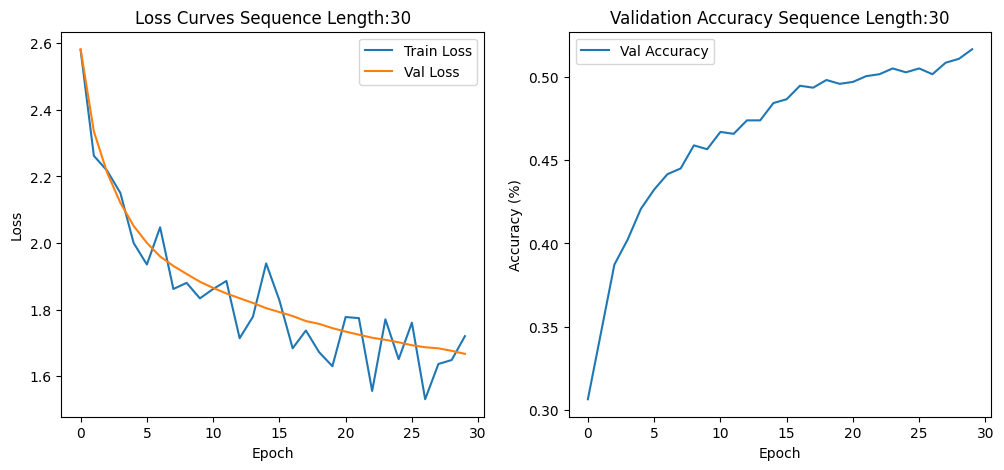

Layer (type:depth-idx)                   Output Shape              Param #
BasicLSTM                                [1, 65]                   --
├─Embedding: 1-1                         [1, 30, 100]              6,500
├─LSTM: 1-2                              [1, 30, 100]              80,800
├─Dropout: 1-3                           [1, 100]                  --
├─Linear: 1-4                            [1, 65]                   6,565
Total params: 93,865
Trainable params: 93,865
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 2.44
Input size (MB): 0.00
Forward/backward pass size (MB): 0.05
Params size (MB): 0.38
Estimated Total Size (MB): 0.42


In [23]:
input_length = 30
model = BasicLSTM(len(sorted_text), len(sorted_text)).to(device)
train_loss_list, val_loss_list, val_accuracy_list, time_list = run(model, input_length)
print(f"avg_time = {sum(time_list) / len(time_list)}")
createPlot(input_length, train_loss_list, val_loss_list, val_accuracy_list)
print(summary(model, input_size = (1,input_length), dtypes=[torch.long]))

##GRU

Train and Test Loader Created - Sequence Length: 30
Epoch 0, Loss: 2.5931, Val Accuracy: 0.3064, Val Loss: 2.4818, Training Time: 8253.994140625ms
Epoch 1, Loss: 2.1831, Val Accuracy: 0.3572, Val Loss: 2.2385, Training Time: 8679.6669921875ms
Epoch 2, Loss: 2.1593, Val Accuracy: 0.3896, Val Loss: 2.1121, Training Time: 8541.90234375ms
Epoch 3, Loss: 2.0818, Val Accuracy: 0.4058, Val Loss: 2.0247, Training Time: 8557.177734375ms
Epoch 4, Loss: 1.9630, Val Accuracy: 0.4277, Val Loss: 1.9607, Training Time: 8562.7900390625ms
Epoch 5, Loss: 1.9239, Val Accuracy: 0.4382, Val Loss: 1.9154, Training Time: 8490.974609375ms
Epoch 6, Loss: 1.7056, Val Accuracy: 0.4532, Val Loss: 1.8805, Training Time: 8528.6494140625ms
Epoch 7, Loss: 1.9174, Val Accuracy: 0.4590, Val Loss: 1.8528, Training Time: 8538.2001953125ms
Epoch 8, Loss: 1.7295, Val Accuracy: 0.4659, Val Loss: 1.8282, Training Time: 8389.9501953125ms
Epoch 9, Loss: 1.8685, Val Accuracy: 0.4717, Val Loss: 1.8099, Training Time: 8593.071289

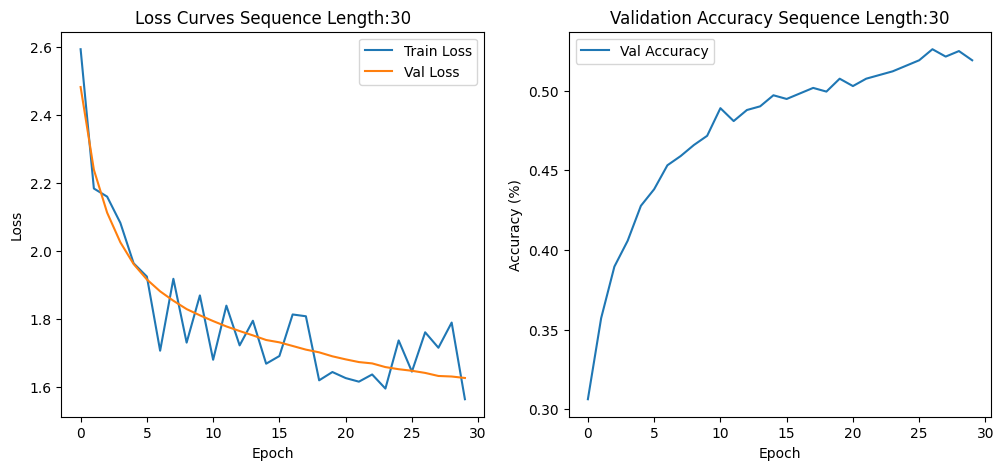

Layer (type:depth-idx)                   Output Shape              Param #
BasicGRU                                 [1, 65]                   --
├─Embedding: 1-1                         [1, 30, 100]              6,500
├─GRU: 1-2                               [1, 30, 100]              60,600
├─Dropout: 1-3                           [1, 100]                  --
├─Linear: 1-4                            [1, 65]                   6,565
Total params: 73,665
Trainable params: 73,665
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 1.83
Input size (MB): 0.00
Forward/backward pass size (MB): 0.05
Params size (MB): 0.29
Estimated Total Size (MB): 0.34


In [24]:
input_length = 30
model = BasicGRU(len(sorted_text), len(sorted_text)).to(device)
train_loss_list, val_loss_list, val_accuracy_list, time_list = run(model, input_length)
print(f"avg_time = {sum(time_list) / len(time_list)}")
createPlot(input_length, train_loss_list, val_loss_list, val_accuracy_list)
print(summary(model, input_size = (1,input_length), dtypes=[torch.long]))

# 2. Adjusted Models

##Input Length 20

##Modified LSTM

Train and Test Loader Created - Sequence Length: 20
Epoch 0, Loss: 2.0709, Val Accuracy: 0.3899, Val Loss: 2.0998, Training Time: 11905.45703125ms
Epoch 1, Loss: 1.9670, Val Accuracy: 0.4648, Val Loss: 1.8637, Training Time: 12337.39453125ms
Epoch 2, Loss: 1.9015, Val Accuracy: 0.4913, Val Loss: 1.7162, Training Time: 12343.4375ms
Epoch 3, Loss: 1.8142, Val Accuracy: 0.5179, Val Loss: 1.6158, Training Time: 12181.43359375ms
Epoch 4, Loss: 1.6904, Val Accuracy: 0.5502, Val Loss: 1.5324, Training Time: 12363.2568359375ms
Epoch 5, Loss: 1.4795, Val Accuracy: 0.5536, Val Loss: 1.4757, Training Time: 12209.677734375ms
Epoch 6, Loss: 1.5228, Val Accuracy: 0.5571, Val Loss: 1.4450, Training Time: 12334.7919921875ms
Epoch 7, Loss: 1.5327, Val Accuracy: 0.5617, Val Loss: 1.4112, Training Time: 12337.2314453125ms
Epoch 8, Loss: 1.5067, Val Accuracy: 0.5698, Val Loss: 1.3999, Training Time: 12156.7353515625ms
Epoch 9, Loss: 1.4740, Val Accuracy: 0.5813, Val Loss: 1.3718, Training Time: 12148.6630

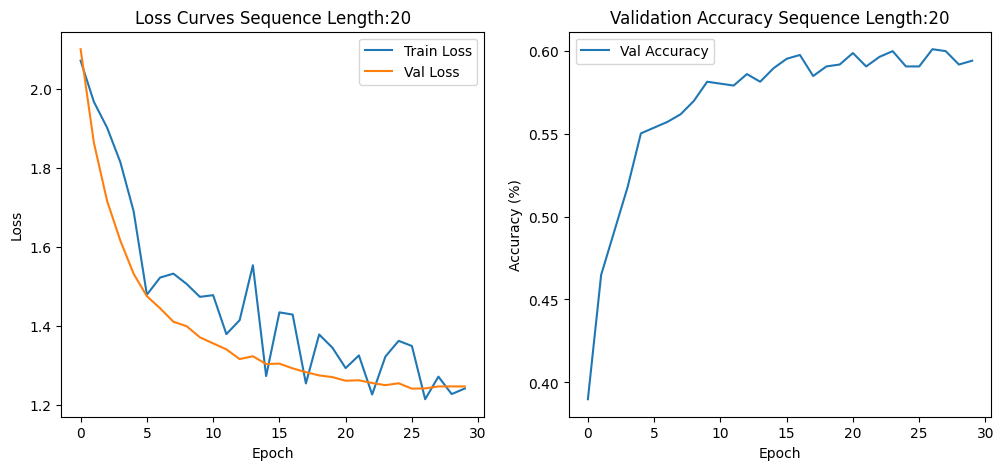

Layer (type:depth-idx)                   Output Shape              Param #
ModifiedLSTM                             [1, 65]                   --
├─Embedding: 1-1                         [1, 20, 512]              33,280
├─LSTM: 1-2                              [1, 20, 512]              6,303,744
├─Dropout: 1-3                           [1, 512]                  --
├─Linear: 1-4                            [1, 128]                  65,664
├─Linear: 1-5                            [1, 65]                   8,385
Total params: 6,411,073
Trainable params: 6,411,073
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 126.18
Input size (MB): 0.00
Forward/backward pass size (MB): 0.17
Params size (MB): 25.64
Estimated Total Size (MB): 25.81


In [25]:
input_length = 20
model = ModifiedLSTM(len(sorted_text), len(sorted_text), 128, dropout_rate=0.3).to(device)
train_loss_list, val_loss_list, val_accuracy_list, time_list = run(model, input_length)
print(f"avg_time = {sum(time_list) / len(time_list)}")
createPlot(input_length, train_loss_list, val_loss_list, val_accuracy_list)
print(summary(model, input_size = (1,input_length), dtypes=[torch.long]))

##Modified GRU

Train and Test Loader Created - Sequence Length: 20
Epoch 0, Loss: 1.9114, Val Accuracy: 0.4510, Val Loss: 1.9082, Training Time: 10429.259765625ms
Epoch 1, Loss: 1.8630, Val Accuracy: 0.4775, Val Loss: 1.7363, Training Time: 10361.2412109375ms
Epoch 2, Loss: 1.6519, Val Accuracy: 0.5040, Val Loss: 1.6285, Training Time: 10536.7802734375ms
Epoch 3, Loss: 1.4693, Val Accuracy: 0.5329, Val Loss: 1.5474, Training Time: 10377.44921875ms
Epoch 4, Loss: 1.5662, Val Accuracy: 0.5444, Val Loss: 1.5062, Training Time: 10539.408203125ms
Epoch 5, Loss: 1.6275, Val Accuracy: 0.5559, Val Loss: 1.4693, Training Time: 10544.572265625ms
Epoch 6, Loss: 1.6525, Val Accuracy: 0.5652, Val Loss: 1.4374, Training Time: 10529.3291015625ms
Epoch 7, Loss: 1.4770, Val Accuracy: 0.5767, Val Loss: 1.4155, Training Time: 10518.2119140625ms
Epoch 8, Loss: 1.5978, Val Accuracy: 0.5779, Val Loss: 1.4063, Training Time: 10526.4951171875ms
Epoch 9, Loss: 1.5678, Val Accuracy: 0.5732, Val Loss: 1.3886, Training Time: 10

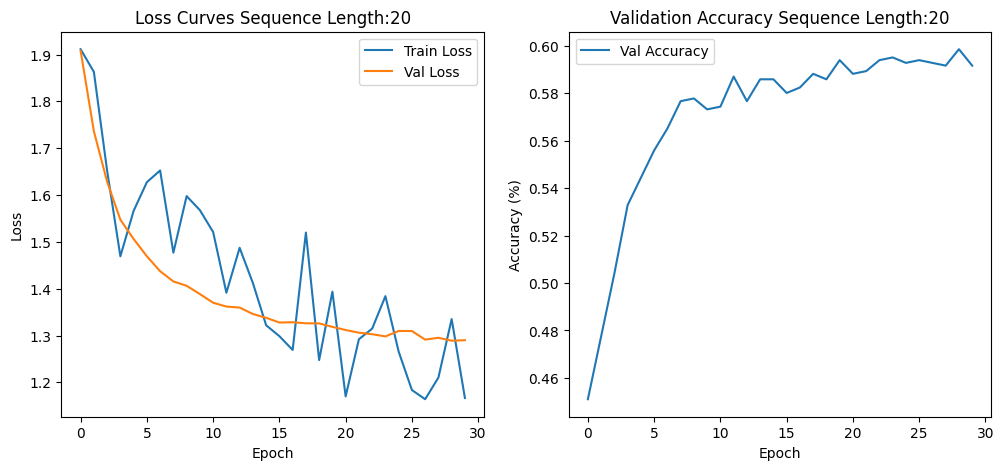

Layer (type:depth-idx)                   Output Shape              Param #
ModifiedGRU                              [1, 65]                   --
├─Embedding: 1-1                         [1, 20, 512]              33,280
├─GRU: 1-2                               [1, 20, 512]              4,727,808
├─Dropout: 1-3                           [1, 512]                  --
├─Linear: 1-4                            [1, 128]                  65,664
├─Linear: 1-5                            [1, 65]                   8,385
Total params: 4,835,137
Trainable params: 4,835,137
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 94.66
Input size (MB): 0.00
Forward/backward pass size (MB): 0.17
Params size (MB): 19.34
Estimated Total Size (MB): 19.51


In [26]:
input_length = 20
model = ModifiedGRU(len(sorted_text), len(sorted_text), 128, dropout_rate=0.3).to(device)
train_loss_list, val_loss_list, val_accuracy_list, time_list = run(model, input_length)
print(f"avg_time = {sum(time_list) / len(time_list)}")
createPlot(input_length, train_loss_list, val_loss_list, val_accuracy_list)
print(summary(model, input_size = (1,input_length), dtypes=[torch.long]))

##Input Length 30

##Modified LSTM

Train and Test Loader Created - Sequence Length: 30
Epoch 0, Loss: 2.2252, Val Accuracy: 0.3931, Val Loss: 2.1113, Training Time: 16568.546875ms
Epoch 1, Loss: 2.1040, Val Accuracy: 0.4763, Val Loss: 1.8438, Training Time: 17337.0390625ms
Epoch 2, Loss: 1.8019, Val Accuracy: 0.5017, Val Loss: 1.7026, Training Time: 17166.2421875ms
Epoch 3, Loss: 1.6844, Val Accuracy: 0.5121, Val Loss: 1.6184, Training Time: 17375.982421875ms
Epoch 4, Loss: 1.5918, Val Accuracy: 0.5214, Val Loss: 1.5626, Training Time: 17235.3515625ms
Epoch 5, Loss: 1.6376, Val Accuracy: 0.5468, Val Loss: 1.5115, Training Time: 17401.595703125ms
Epoch 6, Loss: 1.5076, Val Accuracy: 0.5688, Val Loss: 1.4766, Training Time: 17223.025390625ms
Epoch 7, Loss: 1.2487, Val Accuracy: 0.5688, Val Loss: 1.4606, Training Time: 17411.048828125ms
Epoch 8, Loss: 1.5464, Val Accuracy: 0.5792, Val Loss: 1.4258, Training Time: 17215.560546875ms
Epoch 9, Loss: 1.3431, Val Accuracy: 0.5780, Val Loss: 1.3988, Training Time: 17380.279296875

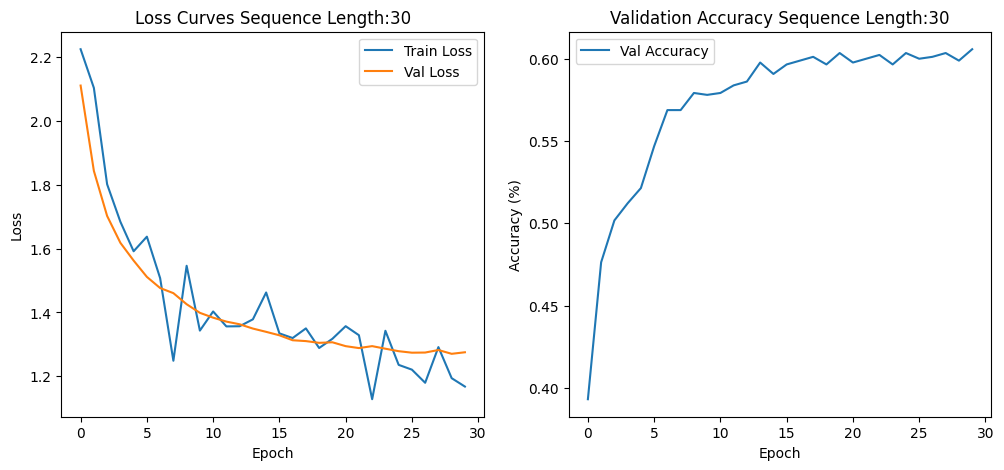

Layer (type:depth-idx)                   Output Shape              Param #
ModifiedLSTM                             [1, 65]                   --
├─Embedding: 1-1                         [1, 30, 512]              33,280
├─LSTM: 1-2                              [1, 30, 512]              6,303,744
├─Dropout: 1-3                           [1, 512]                  --
├─Linear: 1-4                            [1, 128]                  65,664
├─Linear: 1-5                            [1, 65]                   8,385
Total params: 6,411,073
Trainable params: 6,411,073
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 189.22
Input size (MB): 0.00
Forward/backward pass size (MB): 0.25
Params size (MB): 25.64
Estimated Total Size (MB): 25.89


In [27]:
input_length = 30
model = ModifiedLSTM(len(sorted_text), len(sorted_text), 128, dropout_rate=0.3).to(device)
train_loss_list, val_loss_list, val_accuracy_list, time_list = run(model, input_length)
print(f"avg_time = {sum(time_list) / len(time_list)}")
createPlot(input_length, train_loss_list, val_loss_list, val_accuracy_list)
print(summary(model, input_size = (1,input_length), dtypes=[torch.long]))

##Modified GRU

Train and Test Loader Created - Sequence Length: 30
Epoch 0, Loss: 2.0478, Val Accuracy: 0.4231, Val Loss: 1.9679, Training Time: 14583.310546875ms
Epoch 1, Loss: 1.8705, Val Accuracy: 0.4855, Val Loss: 1.7584, Training Time: 14743.451171875ms
Epoch 2, Loss: 1.5966, Val Accuracy: 0.5214, Val Loss: 1.6392, Training Time: 14751.314453125ms
Epoch 3, Loss: 1.5098, Val Accuracy: 0.5329, Val Loss: 1.5606, Training Time: 14578.48828125ms
Epoch 4, Loss: 1.5142, Val Accuracy: 0.5607, Val Loss: 1.5165, Training Time: 14741.1669921875ms
Epoch 5, Loss: 1.5659, Val Accuracy: 0.5769, Val Loss: 1.4685, Training Time: 14758.4638671875ms
Epoch 6, Loss: 1.4694, Val Accuracy: 0.5676, Val Loss: 1.4432, Training Time: 14575.9609375ms
Epoch 7, Loss: 1.4884, Val Accuracy: 0.5757, Val Loss: 1.4222, Training Time: 14555.29296875ms
Epoch 8, Loss: 1.4881, Val Accuracy: 0.5792, Val Loss: 1.3978, Training Time: 14542.0654296875ms
Epoch 9, Loss: 1.4431, Val Accuracy: 0.5827, Val Loss: 1.3904, Training Time: 14717.7

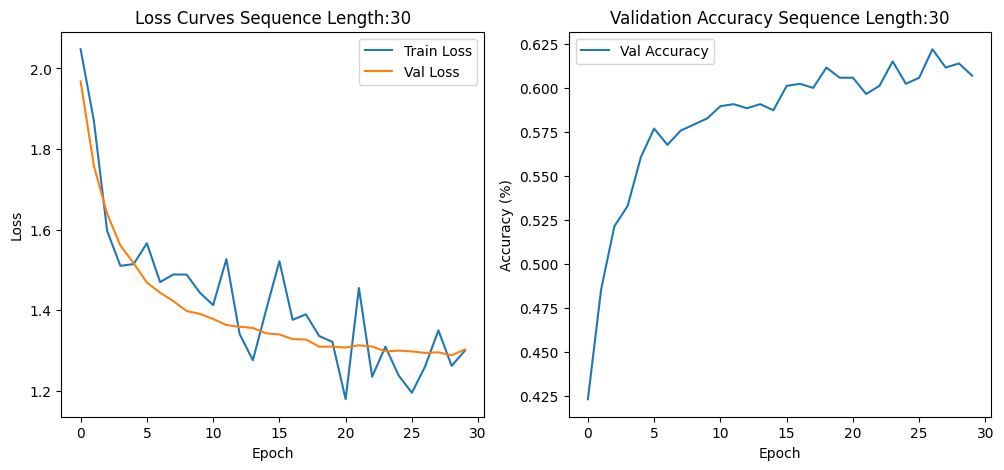

Layer (type:depth-idx)                   Output Shape              Param #
ModifiedGRU                              [1, 65]                   --
├─Embedding: 1-1                         [1, 30, 512]              33,280
├─GRU: 1-2                               [1, 30, 512]              4,727,808
├─Dropout: 1-3                           [1, 512]                  --
├─Linear: 1-4                            [1, 128]                  65,664
├─Linear: 1-5                            [1, 65]                   8,385
Total params: 4,835,137
Trainable params: 4,835,137
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 141.94
Input size (MB): 0.00
Forward/backward pass size (MB): 0.25
Params size (MB): 19.34
Estimated Total Size (MB): 19.59


In [28]:
input_length = 30
model = ModifiedGRU(len(sorted_text), len(sorted_text), 128, dropout_rate=0.3).to(device)
train_loss_list, val_loss_list, val_accuracy_list, time_list = run(model, input_length)
print(f"avg_time = {sum(time_list) / len(time_list)}")
createPlot(input_length, train_loss_list, val_loss_list, val_accuracy_list)
print(summary(model, input_size = (1,input_length), dtypes=[torch.long]))

# 3. Input Length 50

Train and Test Loader Created - Sequence Length: 50
Epoch 0, Loss: 2.5995, Val Accuracy: 0.3333, Val Loss: 2.5102, Training Time: 8053.798828125ms
Epoch 1, Loss: 2.2461, Val Accuracy: 0.3740, Val Loss: 2.2521, Training Time: 8869.4736328125ms
Epoch 2, Loss: 2.0259, Val Accuracy: 0.3984, Val Loss: 2.1344, Training Time: 8900.7607421875ms
Epoch 3, Loss: 2.1558, Val Accuracy: 0.4158, Val Loss: 2.0551, Training Time: 8804.5478515625ms
Epoch 4, Loss: 1.9982, Val Accuracy: 0.4262, Val Loss: 1.9892, Training Time: 8706.904296875ms
Epoch 5, Loss: 2.0031, Val Accuracy: 0.4262, Val Loss: 1.9391, Training Time: 9007.28515625ms
Epoch 6, Loss: 1.9025, Val Accuracy: 0.4448, Val Loss: 1.8971, Training Time: 9214.8837890625ms
Epoch 7, Loss: 1.8478, Val Accuracy: 0.4599, Val Loss: 1.8634, Training Time: 9082.212890625ms
Epoch 8, Loss: 1.7625, Val Accuracy: 0.4646, Val Loss: 1.8365, Training Time: 9015.57421875ms
Epoch 9, Loss: 1.7760, Val Accuracy: 0.4750, Val Loss: 1.8137, Training Time: 9253.73828125

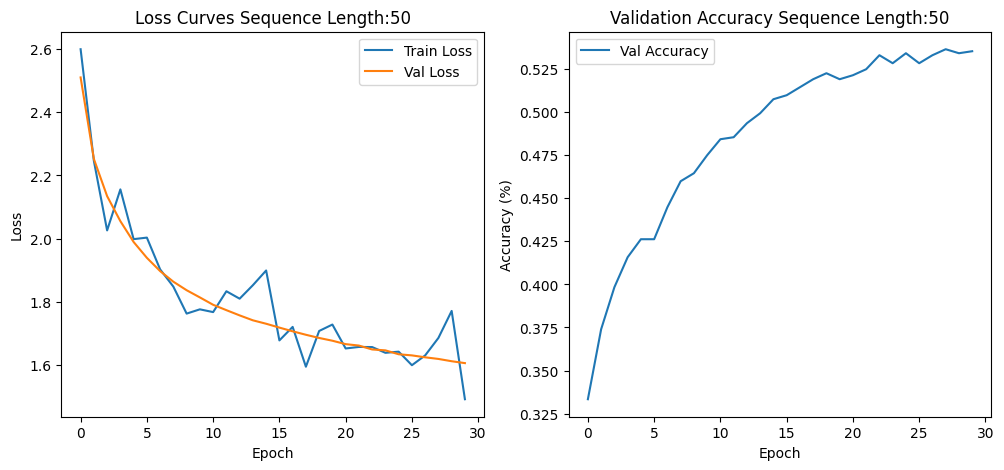

Layer (type:depth-idx)                   Output Shape              Param #
BasicLSTM                                [1, 65]                   --
├─Embedding: 1-1                         [1, 50, 100]              6,500
├─LSTM: 1-2                              [1, 50, 100]              80,800
├─Dropout: 1-3                           [1, 100]                  --
├─Linear: 1-4                            [1, 65]                   6,565
Total params: 93,865
Trainable params: 93,865
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 4.05
Input size (MB): 0.00
Forward/backward pass size (MB): 0.08
Params size (MB): 0.38
Estimated Total Size (MB): 0.46


In [29]:
input_length = 50
model = BasicLSTM(len(sorted_text), len(sorted_text)).to(device)
train_loss_list, val_loss_list, val_accuracy_list, time_list = run(model, input_length)
print(f"avg_time = {sum(time_list) / len(time_list)}")
createPlot(input_length, train_loss_list, val_loss_list, val_accuracy_list)
print(summary(model, input_size = (1,input_length), dtypes=[torch.long]))

Train and Test Loader Created - Sequence Length: 50
Epoch 0, Loss: 2.3140, Val Accuracy: 0.2892, Val Loss: 2.5425, Training Time: 7489.771484375ms
Epoch 1, Loss: 2.1653, Val Accuracy: 0.3380, Val Loss: 2.3066, Training Time: 8629.96875ms
Epoch 2, Loss: 2.0532, Val Accuracy: 0.3693, Val Loss: 2.1842, Training Time: 8711.107421875ms
Epoch 3, Loss: 1.9070, Val Accuracy: 0.3972, Val Loss: 2.1061, Training Time: 8627.0029296875ms
Epoch 4, Loss: 2.1489, Val Accuracy: 0.4100, Val Loss: 2.0512, Training Time: 8888.9013671875ms
Epoch 5, Loss: 1.9055, Val Accuracy: 0.4146, Val Loss: 2.0078, Training Time: 8777.8017578125ms
Epoch 6, Loss: 1.8526, Val Accuracy: 0.4135, Val Loss: 1.9746, Training Time: 8787.4130859375ms
Epoch 7, Loss: 1.9776, Val Accuracy: 0.4193, Val Loss: 1.9422, Training Time: 8796.88671875ms
Epoch 8, Loss: 1.6567, Val Accuracy: 0.4321, Val Loss: 1.9188, Training Time: 8919.1103515625ms
Epoch 9, Loss: 1.8404, Val Accuracy: 0.4379, Val Loss: 1.8931, Training Time: 8782.3095703125

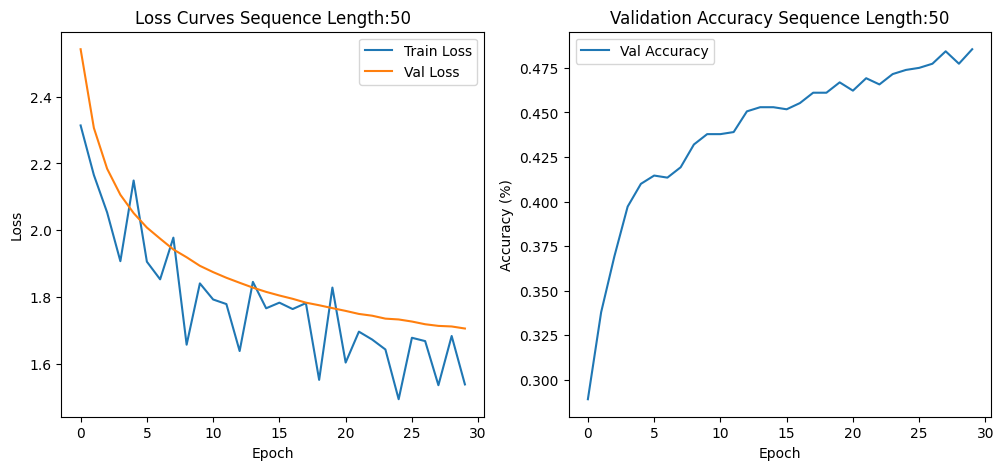

Layer (type:depth-idx)                   Output Shape              Param #
BasicGRU                                 [1, 65]                   --
├─Embedding: 1-1                         [1, 50, 100]              6,500
├─GRU: 1-2                               [1, 50, 100]              60,600
├─Dropout: 1-3                           [1, 100]                  --
├─Linear: 1-4                            [1, 65]                   6,565
Total params: 73,665
Trainable params: 73,665
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 3.04
Input size (MB): 0.00
Forward/backward pass size (MB): 0.08
Params size (MB): 0.29
Estimated Total Size (MB): 0.38


In [30]:
input_length = 50
model = BasicGRU(len(sorted_text), len(sorted_text)).to(device)
train_loss_list, val_loss_list, val_accuracy_list, time_list = run(model, input_length)
print(f"avg_time = {sum(time_list) / len(time_list)}")
createPlot(input_length, train_loss_list, val_loss_list, val_accuracy_list)
print(summary(model, input_size = (1,input_length), dtypes=[torch.long]))

Train and Test Loader Created - Sequence Length: 50
Epoch 0, Loss: 2.1302, Val Accuracy: 0.3902, Val Loss: 2.1305, Training Time: 26584.244140625ms
Epoch 1, Loss: 1.9275, Val Accuracy: 0.4506, Val Loss: 1.8960, Training Time: 27430.015625ms
Epoch 2, Loss: 1.8521, Val Accuracy: 0.4971, Val Loss: 1.7538, Training Time: 27523.716796875ms
Epoch 3, Loss: 1.6546, Val Accuracy: 0.5168, Val Loss: 1.6581, Training Time: 27399.271484375ms
Epoch 4, Loss: 1.6834, Val Accuracy: 0.5319, Val Loss: 1.5865, Training Time: 27358.798828125ms
Epoch 5, Loss: 1.6696, Val Accuracy: 0.5470, Val Loss: 1.5331, Training Time: 27334.369140625ms
Epoch 6, Loss: 1.4260, Val Accuracy: 0.5598, Val Loss: 1.4845, Training Time: 27514.185546875ms
Epoch 7, Loss: 1.5015, Val Accuracy: 0.5714, Val Loss: 1.4423, Training Time: 27417.69140625ms
Epoch 8, Loss: 1.4012, Val Accuracy: 0.5691, Val Loss: 1.4166, Training Time: 27595.3125ms
Epoch 9, Loss: 1.4140, Val Accuracy: 0.5691, Val Loss: 1.4029, Training Time: 27664.66015625m

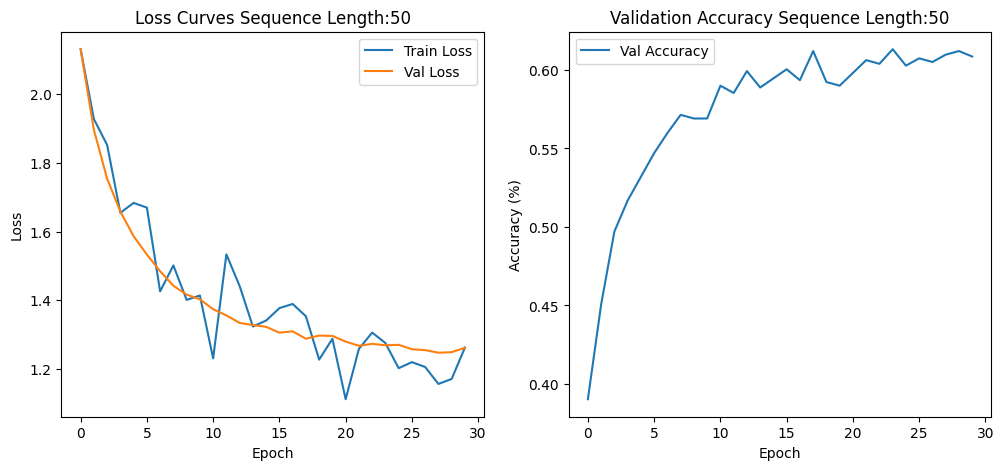

Layer (type:depth-idx)                   Output Shape              Param #
ModifiedLSTM                             [1, 65]                   --
├─Embedding: 1-1                         [1, 50, 512]              33,280
├─LSTM: 1-2                              [1, 50, 512]              6,303,744
├─Dropout: 1-3                           [1, 512]                  --
├─Linear: 1-4                            [1, 128]                  65,664
├─Linear: 1-5                            [1, 65]                   8,385
Total params: 6,411,073
Trainable params: 6,411,073
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 315.29
Input size (MB): 0.00
Forward/backward pass size (MB): 0.41
Params size (MB): 25.64
Estimated Total Size (MB): 26.06


In [31]:
input_length = 50
model = ModifiedLSTM(len(sorted_text), len(sorted_text), 128, dropout_rate=0.3).to(device)
train_loss_list, val_loss_list, val_accuracy_list, time_list = run(model, input_length)
print(f"avg_time = {sum(time_list) / len(time_list)}")
createPlot(input_length, train_loss_list, val_loss_list, val_accuracy_list)
print(summary(model, input_size = (1,input_length), dtypes=[torch.long]))

Train and Test Loader Created - Sequence Length: 50
Epoch 0, Loss: 1.9246, Val Accuracy: 0.4599, Val Loss: 1.8636, Training Time: 22979.251953125ms
Epoch 1, Loss: 1.7142, Val Accuracy: 0.4913, Val Loss: 1.6811, Training Time: 23333.30078125ms
Epoch 2, Loss: 1.7518, Val Accuracy: 0.5180, Val Loss: 1.5880, Training Time: 23277.80859375ms
Epoch 3, Loss: 1.6760, Val Accuracy: 0.5447, Val Loss: 1.5334, Training Time: 23153.37109375ms
Epoch 4, Loss: 1.5886, Val Accuracy: 0.5447, Val Loss: 1.4943, Training Time: 23304.47265625ms
Epoch 5, Loss: 1.3465, Val Accuracy: 0.5505, Val Loss: 1.4680, Training Time: 23266.0ms
Epoch 6, Loss: 1.4270, Val Accuracy: 0.5598, Val Loss: 1.4428, Training Time: 23135.072265625ms
Epoch 7, Loss: 1.4216, Val Accuracy: 0.5633, Val Loss: 1.4231, Training Time: 23194.2734375ms
Epoch 8, Loss: 1.3580, Val Accuracy: 0.5633, Val Loss: 1.4224, Training Time: 23254.431640625ms
Epoch 9, Loss: 1.4333, Val Accuracy: 0.5587, Val Loss: 1.4037, Training Time: 23247.365234375ms
Ep

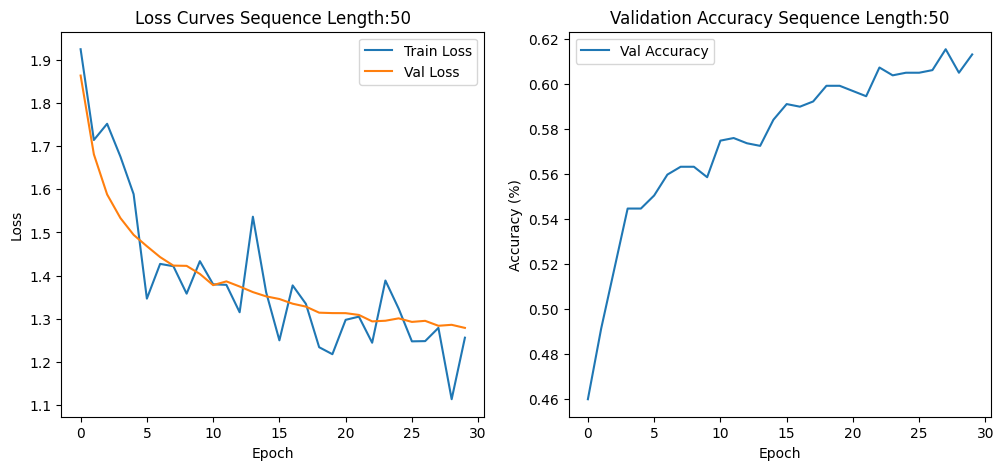

Layer (type:depth-idx)                   Output Shape              Param #
ModifiedGRU                              [1, 65]                   --
├─Embedding: 1-1                         [1, 50, 512]              33,280
├─GRU: 1-2                               [1, 50, 512]              4,727,808
├─Dropout: 1-3                           [1, 512]                  --
├─Linear: 1-4                            [1, 128]                  65,664
├─Linear: 1-5                            [1, 65]                   8,385
Total params: 4,835,137
Trainable params: 4,835,137
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 236.50
Input size (MB): 0.00
Forward/backward pass size (MB): 0.41
Params size (MB): 19.34
Estimated Total Size (MB): 19.75


In [32]:
input_length = 50
model = ModifiedGRU(len(sorted_text), len(sorted_text), 128, dropout_rate=0.3).to(device)
train_loss_list, val_loss_list, val_accuracy_list, time_list = run(model, input_length)
print(f"avg_time = {sum(time_list) / len(time_list)}")
createPlot(input_length, train_loss_list, val_loss_list, val_accuracy_list)
print(summary(model, input_size = (1,input_length), dtypes=[torch.long]))